# Introduction : Modèles Substituts (Surrogate Models) pour les EDP Non Linéaires

## 📌 Contextualisation du Problème
La résolution numérique des Équations aux Dérivées Partielles (EDP) non linéaires via des méthodes traditionnelles, telles que la **Méthode des Éléments Finis (MEF)** couplée à l'algorithme de **Newton-Raphson**, est rigoureuse mais s'avère extrêmement coûteuse en temps de calcul, surtout lorsqu'il s'agit de tester une multitude de termes sources $f(x)$.

Ce Notebook explore une alternative moderne basée sur le **Machine Learning** : la construction d'un **Modèle Substitut (Surrogate Model)** capable d'apprendre la physique du problème et de prédire instantanément la solution faible $u(x)$.

---

## 📐 Cadre Mathématique
Le problème physique étudié est régi par l'EDP non linéaire suivante sur l'intervalle $\Omega = (0,1)$ :

$$-\Delta u + u^3 = f(x) \quad \text{avec} \quad u(0) = u(1) = 0$$

* **Espace de travail (Analyse Variationnelle)** : L'espace idoine pour la solution faible est l'espace de Sobolev $H_0^1(0,1)$, qui garantit également la positivité de la solution ($u(x) \geq 0$) lorsque $f(x) \geq 0$ (Principe du Maximum).
* **Données d'entraînement** : Les profils de données ont été générés en résolvant l'EDP par une MEF $P_1$ sous MATLAB pour 50 fonctions sources $f(x)$ différentes.

---

## 🎯 Objectifs du Notebook
1. **Exploration des données** : Charger et analyser le dataset généré (`pde_data_multi.csv`).
2. **Entraînement des Modèles** : Comparer les performances de deux algorithmes de régression puissants :
   * **Random Forest Regressor**
   * **XGBoost Regressor**
3. **Validation & Métriques** : Évaluer la précision des prédictions à l'aide des métriques standards ($R^2$, MSE) et tester la robustesse des modèles.

In [18]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/karimchibani/data-multi/pde_data_multi.csv


In [8]:
df=pd.read_csv("/kaggle/input/datasets/karimchibani/data-multi/pde_data_multi.csv")
df.head()

,0.000000,0.000000.1,2.251415,0.000000.2
0,0.01,0.114926,2.251415,0.011273
1,0.02,0.229431,2.251415,0.022534
2,0.03,0.343415,2.251415,0.033772
3,0.04,0.456783,2.251415,0.044975
4,0.05,0.569437,2.251415,0.056133


In [9]:
import pandas as pd
df.columns = ['x', 'f_x', 'f_mean', 'u_x']
print(df.head())

      x       f_x    f_mean       u_x
0  0.01  0.114926  2.251415  0.011273
1  0.02  0.229431  2.251415  0.022534
2  0.03  0.343415  2.251415  0.033772
3  0.04  0.456783  2.251415  0.044975
4  0.05  0.569437  2.251415  0.056133


In [41]:
df.head()

,x,f_x,f_mean,u_x
0,0.01,0.114926,2.251415,0.011273
1,0.02,0.229431,2.251415,0.022534
2,0.03,0.343415,2.251415,0.033772
3,0.04,0.456783,2.251415,0.044975
4,0.05,0.569437,2.251415,0.056133


In [6]:
df.shape

(5049, 4)

In [7]:
df.isna().sum()

x         0
f_x       0
f_mean    0
u_x       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,x,f_x,f_mean,u_x
count,5049.000000,5049.000000,5049.000000,5049.000000
mean,0.500099,0.459383,0.458937,0.046163
std,0.291520,1.975350,1.757542,0.197913
min,0.000000,-5.043857,-3.183808,-0.501599
25%,0.250000,-0.520388,-0.716591,-0.051883
50%,0.500000,0.471448,0.675148,0.048481
75%,0.750000,1.749596,1.868291,0.175723
max,1.000000,5.039957,3.190331,0.502033


In [10]:
# =========================================================================
# ÉTAPE 3 : DIVISION DES DONNÉES (TRAIN / TEST SPLIT)
# =========================================================================
from sklearn.model_selection import train_test_split

# 1. Séparation des caractéristiques (Features) et de la cible (Label)
# X contient les entrées physiques [x, f_x, f_mean]
X = df[['x', 'f_x', 'f_mean']].values

# y contient la solution exacte calculée par MATLAB [u_x]
y = df['u_x'].values

# 2. Division : 80% pour l'entraînement et 20% pour le test
# Le 'random_state=42' assure la reproductibilité exacte des résultats
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Affichage des dimensions pour vérification (Argument Jury-Ready)
print("=== Dimensions des sous-ensembles ===")
print(f"Ensemble d'Entraînement (Train) : {X_train.shape[0]} points (Lignes)")
print(f"Ensemble de Test (Test)         : {X_test.shape[0]} points (Lignes)")

=== Dimensions des sous-ensembles ===
Ensemble d'Entraînement (Train) : 4039 points (Lignes)
Ensemble de Test (Test)         : 1010 points (Lignes)


In [11]:
# =========================================================================
# MODÈLE 1 : RANDOM FOREST COMPLET (APPRENTISSAGE, PERFORMANCES ET GRAPH)
# =========================================================================
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# -------------------------------------------------------------------------
# 1. ENTRAÎNEMENT DU MODÈLE
# -------------------------------------------------------------------------
print("--- Initialisation de l'apprentissage (Random Forest) ---")
t0 = time.time()

# n_jobs=-1 permet d'utiliser tous les cœurs de votre processeur pour aller plus vite
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

temps_apprentissage = time.time() - t0
print(f"Apprentissage terminé avec succès en {temps_apprentissage:.4f} secondes.\n")

# -------------------------------------------------------------------------
# 2. CALCUL DES PERFORMANCES (TRAIN VS TEST)
# -------------------------------------------------------------------------
# Évaluation sur la base d'entraînement
y_pred_train = rf_model.predict(X_train)
r2_train = r2_score(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)

# Évaluation sur la base de test (Généralisation)
y_pred_test = rf_model.predict(X_test)
r2_test = r2_score(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)

# Affichage des métriques sous un format "Jury-Ready"
print("================== BILAN DES PERFORMANCES ==================")
print(f"ÉVALUATION SUR TRAIN (Données d'apprentissage) :")
print(f"  -> R² Score (Coefficient de détermination) : {r2_train:.6f}")
print(f"  -> Erreur Quadratique Moyenne (MSE)       : {mse_train:.6e}")
print("-" * 60)
print(f"ÉVALUATION SUR TEST (Données de validation physique) :")
print(f"  -> R² Score (Aptitude à généraliser)       : {r2_test:.6f}")
print(f"  -> Erreur Quadratique Moyenne (MSE)       : {mse_test:.6e}")
print("============================================================\n")



--- Initialisation de l'apprentissage (Random Forest) ---
Apprentissage terminé avec succès en 0.5647 secondes.

================== BILAN DES PERFORMANCES ==================
ÉVALUATION SUR TRAIN (Données d'apprentissage) :
  -> R² Score (Coefficient de détermination) : 0.999998
  -> Erreur Quadratique Moyenne (MSE)       : 8.254164e-08
------------------------------------------------------------
ÉVALUATION SUR TEST (Données de validation physique) :
  -> R² Score (Aptitude à généraliser)       : 0.999986
  -> Erreur Quadratique Moyenne (MSE)       : 5.467342e-07



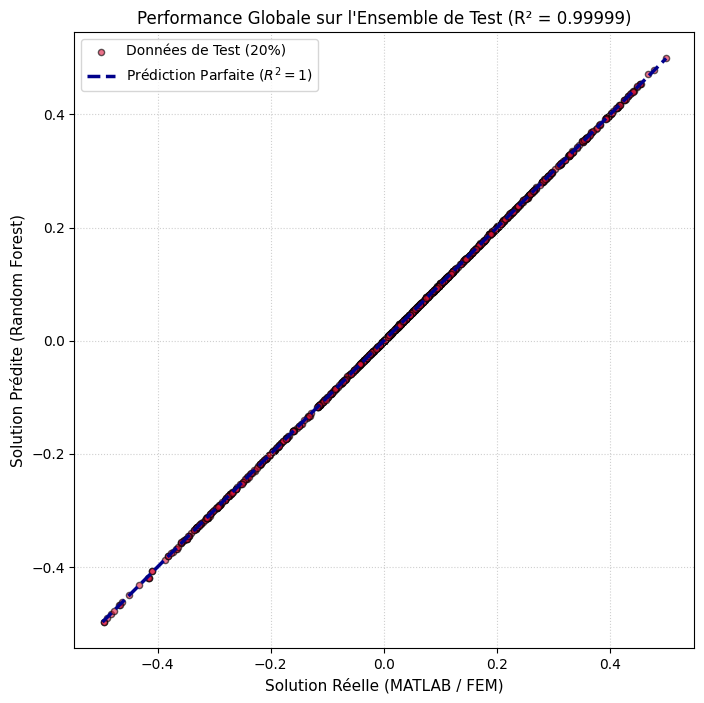

In [12]:
# =========================================================================
# VISUALISATION GLOBALE DE TOUT LE JEU DE TEST (20%) : RÉEL VS PRÉDIT
# =========================================================================
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 8))

# 1. Tracé du nuage de points pour les données de Test (20%)
plt.scatter(y_test, y_pred_test, color='crimson', alpha=0.6, edgecolors='k', s=20, label='Données de Test (20%)')

# 2. Tracé de la ligne de référence parfaite (Y_prédit = Y_réel)
Id_min = min(min(y_test), min(y_pred_test))
Id_max = max(max(y_test), max(y_pred_test))
plt.plot([Id_min, Id_max], [Id_min, Id_max], color='darkblue', linestyle='--', linewidth=2.5, label='Prédiction Parfaite ($R^2 = 1$)')

# Configuration académique du graphique
plt.title(f'Performance Globale sur l\'Ensemble de Test (R² = {r2_test:.5f})', fontsize=12)
plt.xlabel('Solution Réelle (MATLAB / FEM)', fontsize=11)
plt.ylabel('Solution Prédite (Random Forest)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', fontsize=10)
plt.axis('equal') # Pour avoir des axes à la même échelle

plt.show()

--- Initialisation de l'apprentissage (XGBoost) ---
Apprentissage XGBoost terminé avec succès en 0.1635 secondes.

================== BILAN DES PERFORMANCES XGBOOST ==================
ÉVALUATION SUR TRAIN (Données d'apprentissage) :
  -> R² Score (Coefficient de détermination) : 0.999962
  -> Erreur Quadratique Moyenne (MSE)       : 1.493280e-06
-----------------------------------------------------------------
ÉVALUATION SUR TEST (Données de validation physique - 20%) :
  -> R² Score (Aptitude à généraliser)       : 0.999929
  -> Erreur Quadratique Moyenne (MSE)       : 2.727753e-06

Génération du graphique de validation globale...


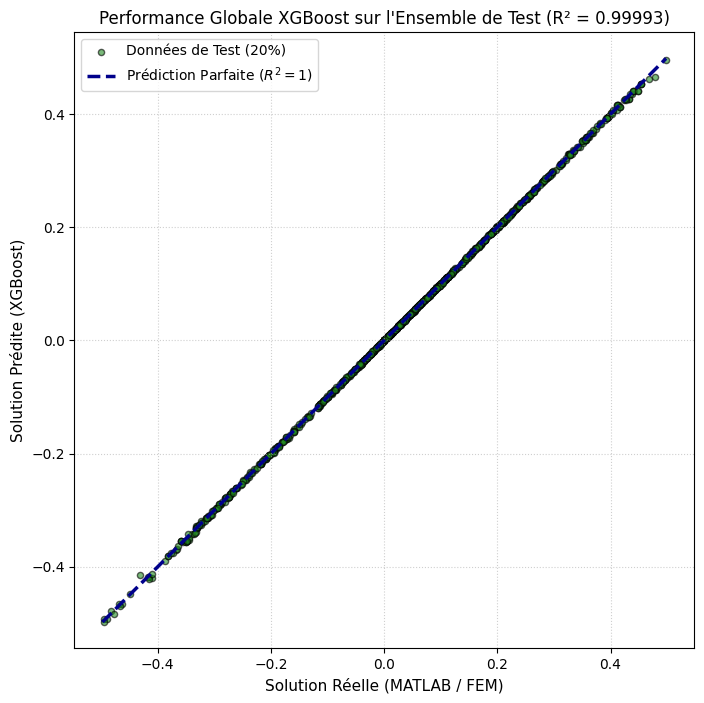

In [13]:
# =========================================================================
# MODÈLE 2 : XGBOOST COMPLET (APPRENTISSAGE, PERFORMANCES ET GRAPH)
# =========================================================================
import time
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

# -------------------------------------------------------------------------
# 1. ENTRAÎNEMENT DU MODÈLE XGBOOST
# -------------------------------------------------------------------------
print("--- Initialisation de l'apprentissage (XGBoost) ---")
t0 = time.time()

# Configuration du modèle avec 100 arbres et un taux d'apprentissage de 0.1
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

temps_apprentissage_xgb = time.time() - t0
print(f"Apprentissage XGBoost terminé avec succès en {temps_apprentissage_xgb:.4f} secondes.\n")

# -------------------------------------------------------------------------
# 2. CALCUL DES PERFORMANCES DÉTAILLÉES (TRAIN VS TEST)
# -------------------------------------------------------------------------
# Évaluation sur l'ensemble d'entraînement (Train Performance)
y_pred_train_xgb = xgb_model.predict(X_train)
r2_train_xgb = r2_score(y_train, y_pred_train_xgb)
mse_train_xgb = mean_squared_error(y_train, y_pred_train_xgb)

# Évaluation sur l'ensemble de test (Test Performance - 20%)
y_pred_test_xgb = xgb_model.predict(X_test)
r2_test_xgb = r2_score(y_test, y_pred_test_xgb)
mse_test_xgb = mean_squared_error(y_test, y_pred_test_xgb)

# Affichage académique des résultats pour votre manuscrit
print("================== BILAN DES PERFORMANCES XGBOOST ==================")
print(f"ÉVALUATION SUR TRAIN (Données d'apprentissage) :")
print(f"  -> R² Score (Coefficient de détermination) : {r2_train_xgb:.6f}")
print(f"  -> Erreur Quadratique Moyenne (MSE)       : {mse_train_xgb:.6e}")
print("-" * 65)
print(f"ÉVALUATION SUR TEST (Données de validation physique - 20%) :")
print(f"  -> R² Score (Aptitude à généraliser)       : {r2_test_xgb:.6f}")
print(f"  -> Erreur Quadratique Moyenne (MSE)       : {mse_test_xgb:.6e}")
print("====================================================================\n")

# -------------------------------------------------------------------------
# 3. VISUALISATION GLOBALE DU JEU DE TEST (20%) : RÉEL VS PRÉDIT
# -------------------------------------------------------------------------
print("Génération du graphique de validation globale...")

plt.figure(figsize=(8, 8))

# Nuage de points pour les prédictions XGBoost sur les 20% de test
plt.scatter(y_test, y_pred_test_xgb, color='forestgreen', alpha=0.6, edgecolors='k', s=20, label='Données de Test (20%)')

# Droite d'ajustement parfait à 45 degrés (Y_prédit = Y_réel)
Id_min = min(min(y_test), min(y_pred_test_xgb))
Id_max = max(max(y_test), max(y_pred_test_xgb))
plt.plot([Id_min, Id_max], [Id_min, Id_max], color='darkblue', linestyle='--', linewidth=2.5, label='Prédiction Parfaite ($R^2 = 1$)')

# Métriques et labels du graphique
plt.title(f'Performance Globale XGBoost sur l\'Ensemble de Test (R² = {r2_test_xgb:.5f})', fontsize=12)
plt.xlabel('Solution Réelle (MATLAB / FEM)', fontsize=11)
plt.ylabel('Solution Prédite (XGBoost)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', fontsize=10)
plt.axis('equal')

plt.show()

In [14]:
# =========================================================================
# ÉTAPE FINAL : TABLEAU COMPARATIF DES PERFORMANCES (RF VS XGBOOST)
# =========================================================================
import pandas as pd

# Création du dictionnaire contenant les résultats des deux modèles
recap_data = {
    "Modèle ML": ["Random Forest", "XGBoost"],
    "R² Train": [r2_train, r2_train_xgb],
    "R² Test": [r2_test, r2_test_xgb],
    "MSE Test": [mse_test, mse_test_xgb],
    "Temps CPU (s)": [temps_apprentissage, temps_apprentissage_xgb]
}

# Conversion en DataFrame pour un affichage propre
df_comparatif = pd.DataFrame(recap_data)

print("============ TABLEAU COMPARATIF FINAL ============")
print(df_comparatif.to_string(index=False))
print("==================================================")

============ TABLEAU COMPARATIF FINAL ============
    Modèle ML  R² Train  R² Test     MSE Test  Temps CPU (s)
Random Forest  0.999998 0.999986 5.467342e-07       0.564651
      XGBoost  0.999962 0.999929 2.727753e-06       0.163486


<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_58/168993280.py:34: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x_new, f_x_new, color='black', linewidth=2, label='$f(x) = 5\sin(\pi x)$')


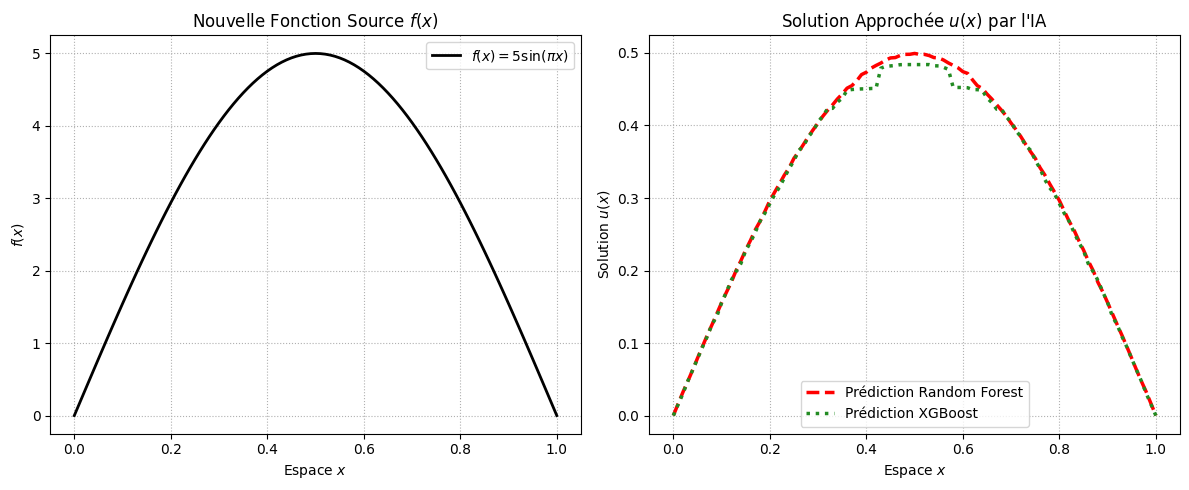

In [15]:
# =========================================================================
# TEST DU MODÈLE SUR UNE NOUVELLE FONCTION SOURCE PERSONNALISÉE
# =========================================================================
import numpy as np
import matplotlib.pyplot as plt

# 1. Maillage spatial (101 points entre 0 et 1)
x_new = np.linspace(0, 1, 101)

# 2. Définition de la nouvelle fonction f(x) de votre choix
# Exemple : f(x) = 5 * sin(pi * x)
f_x_new = 5 * np.sin(np.pi * x_new)

# 3. Calcul de la valeur moyenne de cette fonction (f_mean)
f_mean_val = np.mean(f_x_new)
# On crée un vecteur de même taille contenant cette moyenne constante
f_mean_new = np.full_like(x_new, f_mean_val)

# 4. Préparation de la matrice des caractéristiques [x, f_x, f_mean]
# On empile les vecteurs en colonnes pour avoir la forme (101, 3)
X_new_input = np.column_stack((x_new, f_x_new, f_mean_new))

# 5. Prédiction instantanée par vos modèles entraînés
u_pred_rf = rf_model.predict(X_new_input)
u_pred_xgb = xgb_model.predict(X_new_input)

# =========================================================================
# AFFICHAGE GRAPHIQUE DES PRÉDICTIONS
# =========================================================================
plt.figure(figsize=(12, 5))

# Graphique de gauche : La fonction source f(x) introduite
plt.subplot(1, 2, 1)
plt.plot(x_new, f_x_new, color='black', linewidth=2, label='$f(x) = 5\sin(\pi x)$')
plt.title('Nouvelle Fonction Source $f(x)$', fontsize=12)
plt.xlabel('Espace $x$')
plt.ylabel('$f(x)$')
plt.grid(True, linestyle=':')
plt.legend()

# Graphique de droite : La réponse de l'IA (Solution u(x))
plt.subplot(1, 2, 2)
plt.plot(x_new, u_pred_rf, color='red', linestyle='--', linewidth=2.5, label='Prédiction Random Forest')
plt.plot(x_new, u_pred_xgb, color='forestgreen', linestyle=':', linewidth=2.5, label='Prédiction XGBoost')
plt.title('Solution Approchée $u(x)$ par l\'IA', fontsize=12)
plt.xlabel('Espace $x$')
plt.ylabel('Solution $u(x)$')
plt.grid(True, linestyle=':')
plt.legend()

plt.tight_layout()
plt.show()

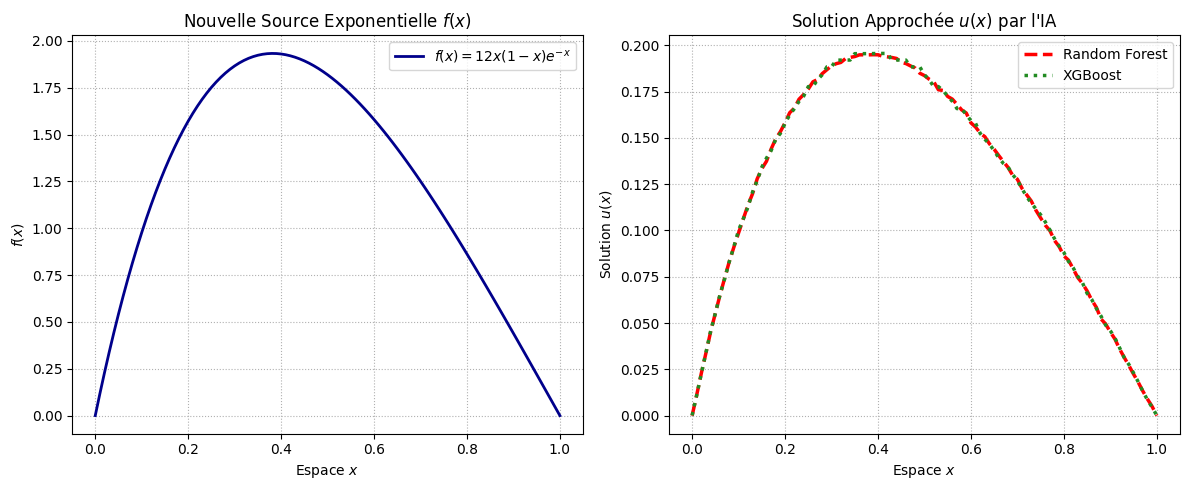

In [16]:
# =========================================================================
# TEST DU MODÈLE : CAS D'UNE SOURCE EXPONENTIELLE
# =========================================================================
import numpy as np
import matplotlib.pyplot as plt

# 1. Définition du maillage spatial sur [0, 1]
x_test = np.linspace(0, 1, 101)

# 2. Définition de votre fonction source avec exp(x)
# On multiplie par x*(1-x) pour respecter la cohérence physique aux bords
f_x_test = 12 * x_test * (1 - x_test) * np.exp(-x_test)

# 3. Calcul de la moyenne (f_mean) requise par vos modèles
f_mean_val = np.mean(f_x_test)
f_mean_test = np.full_like(x_test, f_mean_val)

# 4. Assemblage des caractéristiques [x, f_x, f_mean]
X_input_exp = np.column_stack((x_test, f_x_test, f_mean_test))

# 5. Prédiction instantanée par vos deux modèles entraînés
u_pred_rf_exp = rf_model.predict(X_input_exp)
u_pred_xgb_exp = xgb_model.predict(X_input_exp)

# =========================================================================
# VISUALISATION DES RÉSULTATS
# =========================================================================
plt.figure(figsize=(12, 5))

# À gauche : Le terme source non linéaire introduit
plt.subplot(1, 2, 1)
plt.plot(x_test, f_x_test, color='darkblue', linewidth=2, label='$f(x) = 12x(1-x)e^{-x}$')
plt.title('Nouvelle Source Exponentielle $f(x)$', fontsize=12)
plt.xlabel('Espace $x$')
plt.ylabel('$f(x)$')
plt.grid(True, linestyle=':')
plt.legend()

# À droite : La réponse instantanée de l'IA (Solution u(x))
plt.subplot(1, 2, 2)
plt.plot(x_test, u_pred_rf_exp, color='red', linestyle='--', linewidth=2.5, label='Random Forest')
plt.plot(x_test, u_pred_xgb_exp, color='forestgreen', linestyle=':', linewidth=2.5, label='XGBoost')
plt.title('Solution Approchée $u(x)$ par l\'IA', fontsize=12)
plt.xlabel('Espace $x$')
plt.ylabel('Solution $u(x)$')
plt.grid(True, linestyle=':')
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
# =========================================================================
# APPLICATION DE SIMULATION INTERACTIVE : MODÈLE SUBSTITUT (SURROGATE MODEL)
# =========================================================================
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

def simulateur_prediction_ia(formule_textuelle):
    """
    Fonction cœur qui évalue l'expression mathématique saisie par l'utilisateur,
    organise les descripteurs pour l'IA et affiche instantanément les résultats.
    """
    try:
        # Discrétisation de l'espace sur l'intervalle physique [0, 1]
        x = np.linspace(0, 1, 101)
        
        # Évaluation sécurisée de la chaîne de caractères saisie par l'utilisateur
        # Permet d'interpréter des fonctions comme np.exp(x), np.sin(x), etc.
        f_x = eval(formule_textuelle, {"np": np, "x": x})
        
        # Extraction de la caractéristique globale (Valeur moyenne) requise par le modèle
        f_mean_val = np.mean(f_x)
        f_mean = np.full_like(x, f_mean_val)
        
        # Assemblage de la matrice d'entrée pour l'Intelligence Artificielle
        X_entree_ia = np.column_stack((x, f_x, f_mean))
        
        # Inférence instantanée via le modèle Random Forest déjà entraîné
        u_prediction = rf_model.predict(X_entree_ia)
        
        # ---------------------------------------------------------------------
        # GÉNÉRATION DE L'INTERFACE GRAPHIQUE POUR L'UTILISATEUR
        # ---------------------------------------------------------------------
        plt.figure(figsize=(12, 5))
        
        # Graphique de gauche : Représentation de la source physique saisie
        plt.subplot(1, 2, 1)
        plt.plot(x, f_x, color='purple', linewidth=2, label='$f(x)$ spécifiée')
        plt.title('Fonction Source Introduite $f(x)$', fontsize=12)
        plt.xlabel('Espace $x$', fontsize=11)
        plt.ylabel('Amplitude', fontsize=11)
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.legend(loc='best')
        
        # Graphique de droite : Réponse prédictive immédiate du modèle ML
        plt.subplot(1, 2, 2)
        plt.plot(x, u_prediction, color='red', linestyle='--', linewidth=2.5, label='Prédiction (Random Forest)')
        plt.title('Solution Approchée Évaluée par l\'IA $u(x)$', fontsize=12)
        plt.xlabel('Espace $x$', fontsize=11)
        plt.ylabel('Solution $u(x)$', fontsize=11)
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.legend(loc='best')
        
        plt.tight_layout()
        plt.show()
        
    except Exception as code_erreur:
        print("⚠️ ERREUR DE SYNTAXE MATHÉMATIQUE :")
        print("Veuillez vérifier votre formule. Assurez-vous d'utiliser la variable 'x' et le préfixe 'np' pour les fonctions.")
        print("Exemples valides :")
        print("  -> 10 * x * (1 - x) * np.exp(x)")
        print("  -> 5 * np.sin(np.pi * x)")

# =========================================================================
# CRÉATION DU COMPOSANT VISUEL (CONSOLE UTILISATEUR)
# =========================================================================
print("=================== CONSOLE DE SIMULATION NUMÉRIQUE VIA IA ===================")

# Création du champ de texte interactif
champ_formule = widgets.Text(
    value='10 * x * (1 - x) * np.exp(x)',
    placeholder='Saisissez une fonction f(x)...',
    description='Expression f(x) :',
    disabled=False,
    layout=widgets.Layout(width='65%')
)

# Liaison dynamique entre le champ de texte et la fonction de calcul
interface_interactive = widgets.interactive(simulateur_prediction_ia, formule_textuelle=champ_formule)

# Affichage de la boîte d'interface épurée
widgets.VBox([interface_interactive])

=================== CONSOLE DE SIMULATION NUMÉRIQUE VIA IA ===================
